# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

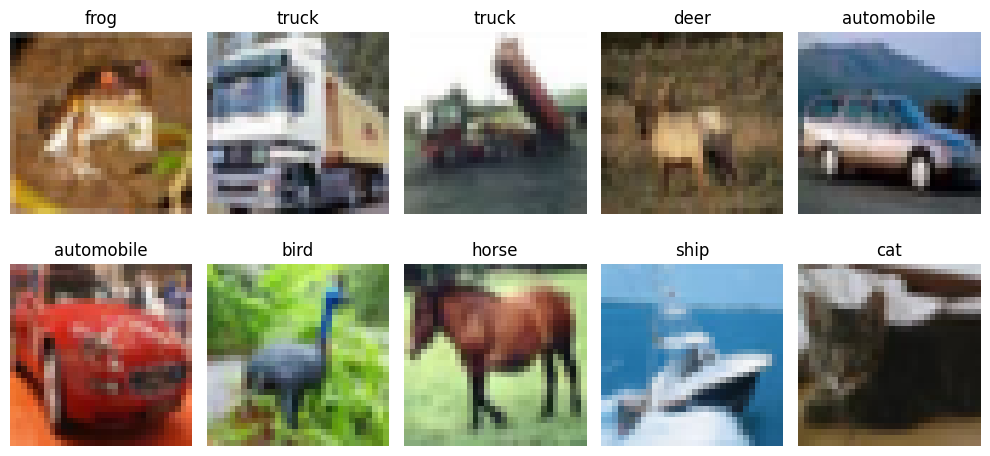

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
#  ANN (original - 2 hidden layers, 10 epochs)
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2699 - loss: 2.0006 - val_accuracy: 0.3482 - val_loss: 1.8348
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3148 - loss: 1.8737 - val_accuracy: 0.3592 - val_loss: 1.7918
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3309 - loss: 1.8233 - val_accuracy: 0.3626 - val_loss: 1.7870
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3468 - loss: 1.7900 - val_accuracy: 0.3740 - val_loss: 1.7388
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3578 - loss: 1.7586 - val_accuracy: 0.3788 - val_loss: 1.7171
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3660 - loss: 1.7391 - val_accuracy: 0.3878 - val_loss: 1.7029
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3762 - loss: 1.7208 - val_accuracy: 0.4022 - val_loss: 1.6857
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3779 - loss: 1.7047 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4022 - loss: 1.6544
ANN Test Accuracy: 0.40220001339912415


## Task 1 (MORE LAYERS IN ANN)

In [7]:
# Task 1: Deeper ANN with more Dense layers
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_history = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_v2_test_loss, ann_v2_test_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_v2_test_acc)
print("Baseline ANN Test Accuracy:", ann_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2328 - loss: 2.0472 - val_accuracy: 0.2966 - val_loss: 1.9371
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2983 - loss: 1.9073 - val_accuracy: 0.3406 - val_loss: 1.8323
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3175 - loss: 1.8544 - val_accuracy: 0.3452 - val_loss: 1.8098
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3291 - loss: 1.8223 - val_accuracy: 0.3914 - val_loss: 1.7722
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3428 - loss: 1.7965 - val_accuracy: 0.3600 - val_loss: 1.7735
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3496 - loss: 1.7837 - val_accuracy: 0.3768 - val_loss: 1.7482
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3588 - loss: 1.7615 - val_accuracy: 0.3890 - val_loss: 1.7216
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3614 - loss: 1.7541 - val_accuracy: 0.

## Task 3 : 20 epochs

In [ ]:
# Task 3 (ANN): Original architecture, trained for 20 epochs
ann_model_20ep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_20ep_history = ann_model_20ep.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

ann_20ep_test_loss, ann_20ep_test_acc = ann_model_20ep.evaluate(x_test_flat, y_test)
print("ANN 20 Epochs Test Accuracy:", ann_20ep_test_acc)
print("Baseline ANN (10 epochs) Test Accuracy:", ann_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2728 - loss: 1.9915 - val_accuracy: 0.3442 - val_loss: 1.8480
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3210 - loss: 1.8649 - val_accuracy: 0.3558 - val_loss: 1.7709
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3402 - loss: 1.8107 - val_accuracy: 0.3850 - val_loss: 1.7460
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3516 - loss: 1.7802 - val_accuracy: 0.3922 - val_loss: 1.7296
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3637 - loss: 1.7443 - val_accuracy: 0.3928 - val_loss: 1.7086
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3736 - loss: 1.7299 - val_accuracy: 0.4090 - val_loss: 1.6748
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3793 - loss: 1.7086 - val_accuracy: 0.4082 - val_loss: 1.6724
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3848 - loss: 1.6926 - val_accuracy: 0.

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
# Baseline CNN (original - 32->64->128 filters, 10 epochs)
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.4698 - loss: 1.4858 - val_accuracy: 0.5518 - val_loss: 1.2995
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6141 - loss: 1.1112 - val_accuracy: 0.5052 - val_loss: 1.4634
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6762 - loss: 0.9379 - val_accuracy: 0.6752 - val_loss: 0.9396
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7112 - loss: 0.8346 - val_accuracy: 0.6548 - val_loss: 1.0091
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7393 - loss: 0.7451 - val_accuracy: 0.6880 - val_loss: 0.9498
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7682 - loss: 0.6670 - val_accuracy: 0.7266 - val_loss: 0.8373
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7913 - loss: 0.5983 - val_accuracy: 0.7036 - val_loss: 0.9201
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8126 - loss: 0.5341 - 

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7270 - loss: 0.8667
CNN Test Accuracy: 0.7269999980926514


## Task 2 increased filters 

In [ ]:
# Task 2: CNN with scaled-up filters (64 -> 128 -> 256)
cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_v2_history = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_v2_test_loss, cnn_v2_test_acc = cnn_model_v2.evaluate(x_test_norm, y_test)
print("Scaled Filters CNN (64-128-256), 10 epochs, Test Accuracy:", cnn_v2_test_acc)
print("Baseline CNN (32-64-128), 10 epochs, Test Accuracy:", cnn_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.4482 - loss: 1.5457 - val_accuracy: 0.3990 - val_loss: 1.8325
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5910 - loss: 1.1745 - val_accuracy: 0.5338 - val_loss: 1.4446
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.6648 - loss: 0.9718 - val_accuracy: 0.6558 - val_loss: 0.9969
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.7142 - loss: 0.8302 - val_accuracy: 0.6476 - val_loss: 1.0554
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.7495 - loss: 0.7197 - val_accuracy: 0.6988 - val_loss: 0.9043
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.7839 - loss: 0.6234 - val_accuracy: 0.6718 - val_loss: 1.0001
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.8110 - loss: 0.5411 - val_accuracy: 0.7090 - val_loss: 0.9263
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.8359 - loss: 0.4690 - 

## Task 3 20 epochs

In [ ]:
# Task 3 (CNN): Original filters (32->64->128), epochs increased to 20
cnn_model_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_model_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_model_20ep.evaluate(x_test_norm, y_test)
print("CNN 20 Epochs (original filters) Test Accuracy:", cnn_20ep_test_acc)
print("Baseline CNN (10 epochs) Test Accuracy:", cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.4629 - loss: 1.4988 - val_accuracy: 0.5416 - val_loss: 1.2985
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6038 - loss: 1.1284 - val_accuracy: 0.5824 - val_loss: 1.1995
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6682 - loss: 0.9592 - val_accuracy: 0.6030 - val_loss: 1.1361
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7115 - loss: 0.8317 - val_accuracy: 0.6572 - val_loss: 1.0510
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7455 - loss: 0.7310 - val_accuracy: 0.6478 - val_loss: 1.0404
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7685 - loss: 0.6588 - val_accuracy: 0.7314 - val_loss: 0.8038
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7950 - loss: 0.5845 - val_accuracy: 0.7066 - val_loss: 0.9040
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8100 - loss: 0.5365 - 

## Task 4:Early stopping 

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Task 4: CNN with EarlyStopping
cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_history = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_model_es.evaluate(x_test_norm, y_test)
print("CNN with EarlyStopping Test Accuracy:", cnn_es_test_acc)
print("Number of epochs actually run:", len(cnn_es_history.history['loss']))

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4609 - loss: 1.4980 - val_accuracy: 0.5716 - val_loss: 1.2132
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6043 - loss: 1.1340 - val_accuracy: 0.6066 - val_loss: 1.1055
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6625 - loss: 0.9678 - val_accuracy: 0.6398 - val_loss: 1.0908
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7086 - loss: 0.8448 - val_accuracy: 0.6778 - val_loss: 0.9194
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7397 - loss: 0.7452 - val_accuracy: 0.6836 - val_loss: 0.9231
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7627 - loss: 0.6823 - val_accuracy: 0.7122 - val_loss: 0.8751
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7882 - loss: 0.5995 - val_accuracy: 0.6868 - val_loss: 0.9628
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8120 - loss: 0.5324 - 

# 🚀TASK 5: Training Strategy Upgrade: Data Augmentation     

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])


aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Baseline CNN Test Accuracy:", cnn_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3679 - loss: 1.7331 - val_accuracy: 0.4748 - val_loss: 1.4481
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4670 - loss: 1.4825 - val_accuracy: 0.5312 - val_loss: 1.2942
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5045 - loss: 1.3887 - val_accuracy: 0.5418 - val_loss: 1.2719
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5277 - loss: 1.3348 - val_accuracy: 0.5946 - val_loss: 1.1355
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5392 - loss: 1.2957 - val_accuracy: 0.5912 - val_loss: 1.1463
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5532 - loss: 1.2599 - val_accuracy: 0.6086 - val_loss: 1.0893
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5658 - loss: 1.2314 - val_accuracy: 0.6002 - val_loss: 1.1490
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5741 - loss: 1.2145 - val_accu

 ## 📈 Compare Learning Curves


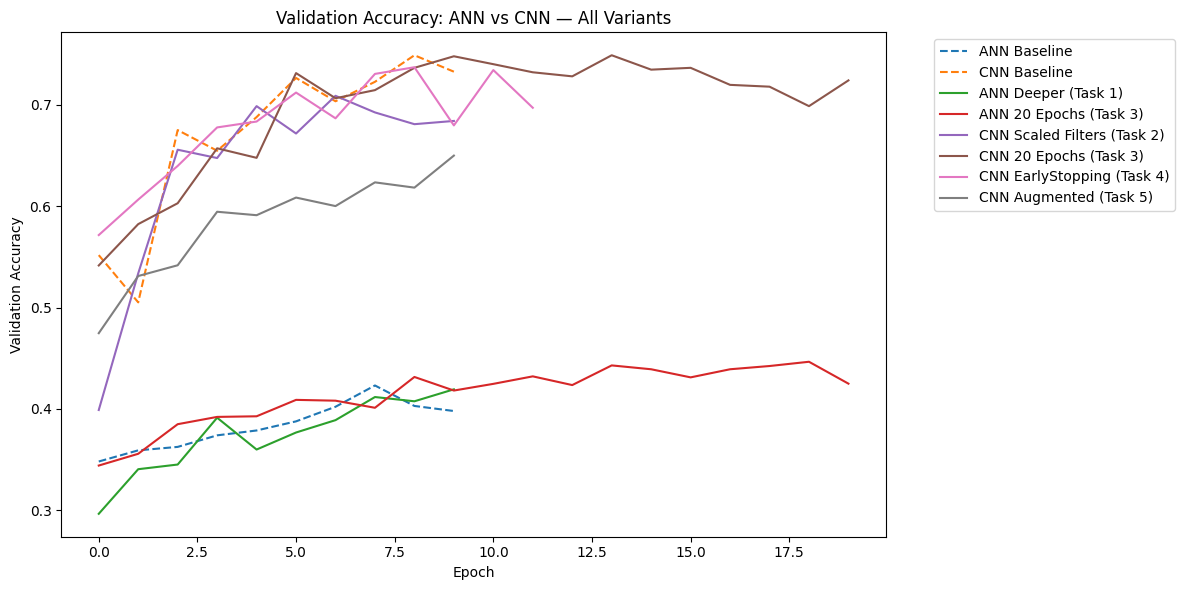

In [15]:
plt.figure(figsize=(12,6))

plt.plot(ann_history.history['val_accuracy'], label='ANN Baseline', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Baseline', linestyle='--')

plt.plot(ann_v2_history.history['val_accuracy'], label='ANN Deeper (Task 1)')
plt.plot(ann_20ep_history.history['val_accuracy'], label='ANN 20 Epochs (Task 3)')

plt.plot(cnn_v2_history.history['val_accuracy'], label='CNN Scaled Filters (Task 2)')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 20 Epochs (Task 3)')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN EarlyStopping (Task 4)')
plt.plot(aug_history.history['val_accuracy'], label='CNN Augmented (Task 5)')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: ANN vs CNN — All Variants")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 📊 Final Comparison Table

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "ANN Baseline", "ANN Deeper (Task 1)", "ANN 20 Epochs (Task 3)",
        "CNN Baseline", "CNN Scaled Filters (Task 2)", "CNN 20 Epochs (Task 3)",
        "CNN EarlyStopping (Task 4)", "CNN Augmented (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc, ann_v2_test_acc, ann_20ep_test_acc,
        cnn_test_acc, cnn_v2_test_acc, cnn_20ep_test_acc,
        cnn_es_test_acc, aug_test_acc
    ]
})
comparison = comparison.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
comparison

,Model,Test Accuracy
0,CNN Baseline,0.7270
1,CNN EarlyStopping (Task 4),0.7216
2,CNN 20 Epochs (Task 3),0.7008
3,CNN Scaled Filters (Task 2),0.6652
4,CNN Augmented (Task 5),0.6461
5,ANN Deeper (Task 1),0.4177
6,ANN 20 Epochs (Task 3),0.4173
7,ANN Baseline,0.4022


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**